# Import packages

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

from utils.ref_subtraction import compute_reference, compute_mean_errors
from utils.plotting import plot_histogram_distributions, plot_feature_space
from utils.mahalanobis import extract_features_from_df, Mahalanobis

# Load data

In [2]:
train_df = pd.read_parquet('data/processed/train.parquet')
test_df = pd.read_parquet('data/processed/test.parquet')

Since are just baseline models, the hyperparam df will not be used separately. Instead, it will be concatenated with the threshold df and used for threshold decision.

In [3]:
hyperparam_df = pd.read_parquet('data/processed/hyperparam.parquet')
threshold_df = pd.read_parquet('data/processed/threshold.parquet')

val_df = pd.concat([hyperparam_df, threshold_df], axis=0).reset_index(drop=True)

In [4]:
# Columns with time series data (t1, t2, ..., t140)
ts_columns = [col for col in train_df.columns if re.match(r't\d+$', col)]

# Baseline Models

Before implementing the Conv1D Autoencoder, two methods will be tested as baselines:

1. **Reference subtraction**: builds a pointwise reference (median and IQR) from the normal training series, then classifies an unseen series based on the aggregated error against that reference.
2. **Mahalanobis distance**: uses summary statistics extracted from the time series, measuring how far each series deviates from the normal distribution in feature space. Provides a purely statistical baseline for comparison.

## 1. Reference subtraction

From the training set, a point-wise reference containing the median and IQR will be built.

Then, for an unseen series the procedure is as follows:
- Compute the error for each point: $error_i = |x_i - median_i| / (IQR_i + \epsilon)$, where $\epsilon$ is a small value that avoids a possible division by 0.
- Then, all the errors for the time series are aggregated using the mean and this mean is used as the classification metric for the window level.
- In order to generate the binary label, a threshold will be applied to the mean error of the series.

The threshold will be defined using the labeled validation dataset.

In [ ]:
# Compute the reference medians and IQRs from the training data
reference_medians, reference_iqrs = compute_reference(train_df[ts_columns])

# Returns the mean error of each of the validation samples
validation_errors = compute_mean_errors(val_df[ts_columns], reference_medians, reference_iqrs)

Below the distributions of the errers are plotted in a histogram. Using this histogram, a threshold is defined in order to separate the normal and anomalous distributions.

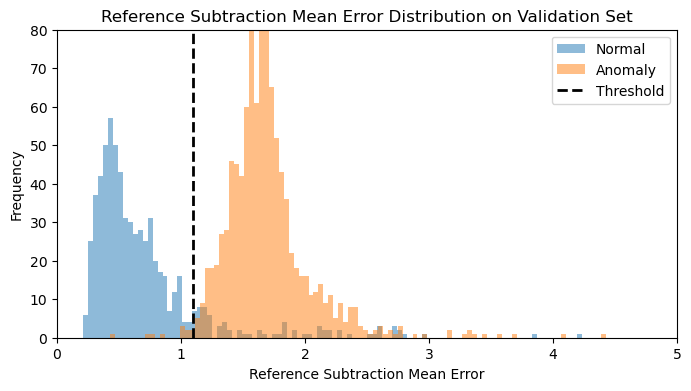

In [6]:
labels = val_df['detailedTarget'].map(lambda x: 'Normal' if x == 'Normal' else 'Anomaly')
normal_mask = labels == 'Normal'
anomaly_mask = labels == 'Anomaly'

plot_histogram_distributions(
    title='Reference Subtraction Mean Error Distribution on Validation Set',
    xlabel='Reference Subtraction Mean Error',
    points=[validation_errors[normal_mask], validation_errors[anomaly_mask]],
    labels=['Normal', 'Anomaly'],
    figsize=(8, 4),
    xlim=[0, 5],
    ylim=[0, 80],
    threshold=1.1
)

Using the threshold defined above, it is possible to classify the test data and compute the score metrics for this method.

In [7]:
th = 1.1

test_errors = compute_mean_errors(test_df[ts_columns], reference_medians, reference_iqrs)
test_labels = test_df['detailedTarget'].map(lambda x: 0 if x == 'Normal' else 1)

predicted_labels = (test_errors > th).astype(int)

### Results

As shown below, the method produced 8 False Negatives and 32 False Positives. Given the simplicity of the model, this is a fantastic result.

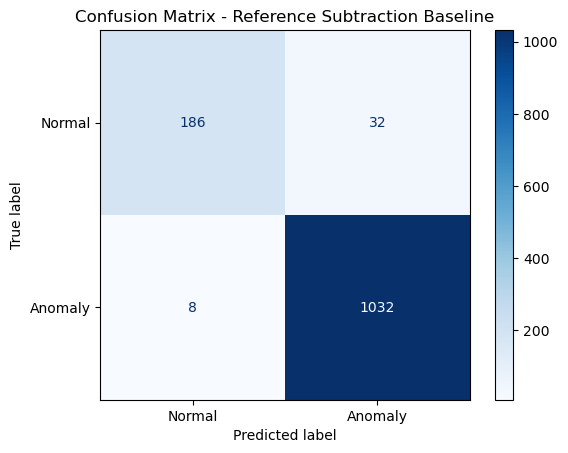

In [8]:
ConfusionMatrixDisplay.from_predictions(
    test_labels, predicted_labels,
    display_labels=['Normal', 'Anomaly'],
    cmap='Blues'
)
plt.title('Confusion Matrix - Reference Subtraction Baseline')
plt.show()

Analyzing more metrics such as Precision, Recall and the F1-Score:

In [9]:
print(classification_report(test_labels, predicted_labels, target_names=['Normal', 'Anomaly']))

              precision    recall  f1-score   support

      Normal       0.96      0.85      0.90       218
     Anomaly       0.97      0.99      0.98      1040

    accuracy                           0.97      1258
   macro avg       0.96      0.92      0.94      1258
weighted avg       0.97      0.97      0.97      1258



Note that the F1-score for the Anomaly class is extremely high (0.98) while for the Normal class it is 0.9. This happens because the test set is mostly composed of anomalous examples, since most of the normal examples were reserved for training and validation.

In [10]:
labels = test_df['detailedTarget'].map(lambda x: 0 if x == 'Normal' else 1)
labels.value_counts(normalize=True)

detailedTarget
1    0.826709
0    0.173291
Name: proportion, dtype: float64

Then, the better alternative is to use the macro avg F1-score, which is the simple mean of the F1-scores of both classes and therefore treats each class with equal weight.

Macro avg F1: 0.94

### Reference Subtraction Results investigation

For explainability, recall the figure below obtained during the EDA. This figure shows that the normal series follow a very stable pattern, which makes this simple method really strong. And since this experiment contains only normal series in the training data, the model performed remarkably well.

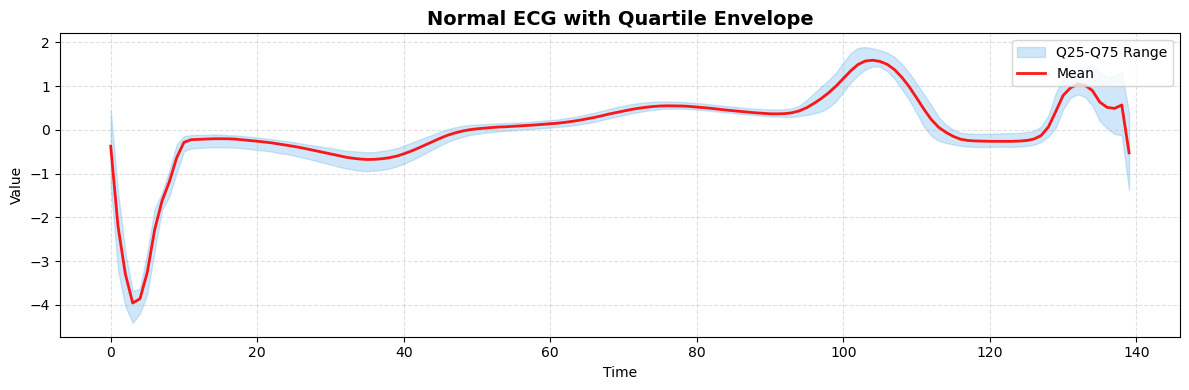

## 2. Mahalanobis distance with threshold

The Mahalanobis distance measures how far a data point is from the center of a distribution, taking into account the variance and correlation between features. Unlike Euclidean distance, it accounts for the shape of the data by using the covariance matrix, effectively normalizing across all dimensions simultaneously. In this notebook, from each time series, `n` summary statistical features are extracted. Therefore, each time series became a point in a `n` dimensional space. Points with a large Mahalanobis distance from the normal distribution are likely to represent anomalies.

Below 9 features (mean, std, min, max, amplitude, quartiles, ...) are extracted from each time series. 

In [11]:
train_features = extract_features_from_df(train_df[ts_columns])
val_features = extract_features_from_df(val_df[ts_columns])
test_features = extract_features_from_df(test_df[ts_columns])

Then the model is trained in normal data:

In [12]:
malahanobis_model = Mahalanobis()
malahanobis_model.fit(train_features)

Below the distributions of the mahalanobis distances are plotted in a histogram. Using this histogram, a threshold is defined in order to separate the normal and anomalous distributions.

Visually, a good choice for the threshold would be 3.5.

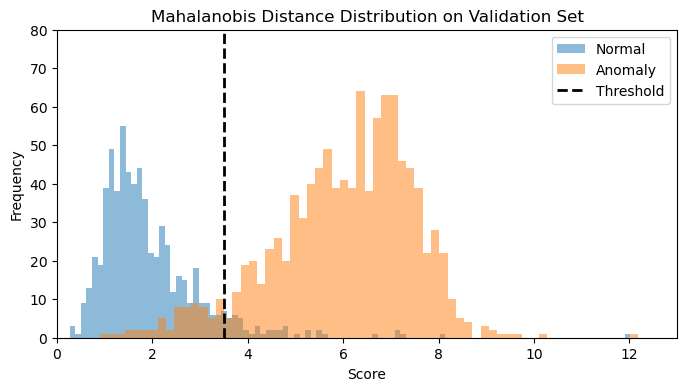

In [13]:
val_scores = malahanobis_model.score(val_features)

labels = val_df['detailedTarget'].map(lambda x: 'Normal' if x == 'Normal' else 'Anomaly')
normal_mask = labels == 'Normal'
anomaly_mask = labels == 'Anomaly'

plot_histogram_distributions(
    title='Mahalanobis Distance Distribution on Validation Set',
    xlabel='Score',
    points=[val_scores[normal_mask], val_scores[anomaly_mask]],
    labels=['Normal', 'Anomaly'],
    figsize=(8, 4),
    xlim=[0, 13],
    ylim=[0, 80],
    threshold=3.5
)

Using the threshold defined above, it is possible to classify the test data and compute the score metrics for this method.

In [14]:
th = 3.5

test_scores = malahanobis_model.score(test_features)
test_labels = test_df['detailedTarget'].map(lambda x: 0 if x == 'Normal' else 1)

predicted_labels = (test_scores > th).astype(int)

### Results

As shown below, the model produced 47 False Negatives and 23 False Positives. The 47 False Negatives represent a considerable concern, as these are anomalies that went undetected.

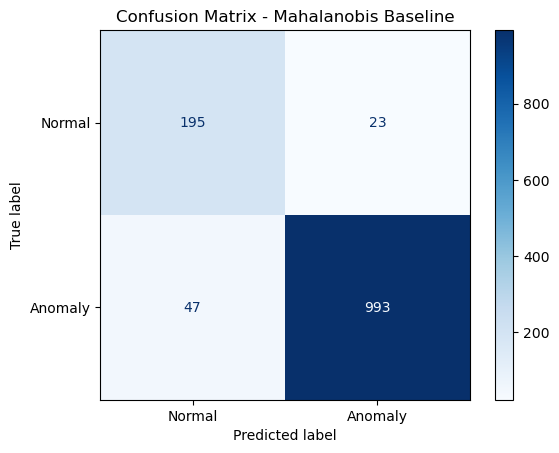

In [15]:
ConfusionMatrixDisplay.from_predictions(
    test_labels, predicted_labels,
    display_labels=['Normal', 'Anomaly'],
    cmap='Blues'
)
plt.title('Confusion Matrix - Mahalanobis Baseline')
plt.show()

Analyzing more metrics such as Precision, Recall and the F1-Score:

In [16]:
print(classification_report(test_labels, predicted_labels, target_names=['Normal', 'Anomaly']))

              precision    recall  f1-score   support

      Normal       0.81      0.89      0.85       218
     Anomaly       0.98      0.95      0.97      1040

    accuracy                           0.94      1258
   macro avg       0.89      0.92      0.91      1258
weighted avg       0.95      0.94      0.95      1258



Macro avg F1: 0.91

### Mahalanobis Results investigation

Since the method above performed considerably well for its simplicity, in this section the statistical characteristics of the data will be investigated. Note that this is only a explainability analysis and was not used for model selection nor for feature selection in the Mahalanobis method.

In [17]:
# Load all data
full_df = pd.read_parquet("data/processed/full.parquet")

# Condense anomaly types into a single "Anomaly" class
full_df['label'] = full_df['detailedTarget'].map(lambda x: 'Normal' if x == 'Normal' else 'Anomaly')

# Extract some features for the full dataset (all of them were used in mahalanobis)
full_df['mean'] = full_df[ts_columns].mean(axis=1)
full_df['std'] = full_df[ts_columns].std(axis=1)
full_df['median'] = full_df[ts_columns].median(axis=1)
full_df['amplitude'] = full_df[ts_columns].max(axis=1) - full_df[ts_columns].min(axis=1)

As shown below, the combination of mean and std alone does not produce a clear separation between classes. Therefore, another combination is tried below.

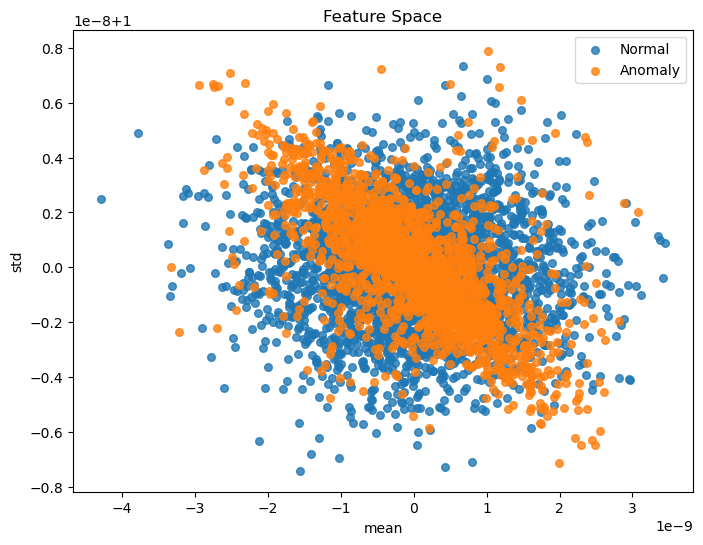

In [18]:
plot_feature_space(
    df=full_df,
    feature_columns=['mean', 'std'],
    label_column='label',
    alpha=0.8,
    figsize=(8, 6)
)

The combination of amplitude and median shows a much clearer separation. Normal series tend to cluster at higher amplitudes, while anomalies concentrate at lower amplitudes with higher median values. This suggests that amplitude is a key discriminative feature for the Mahalanobis method.

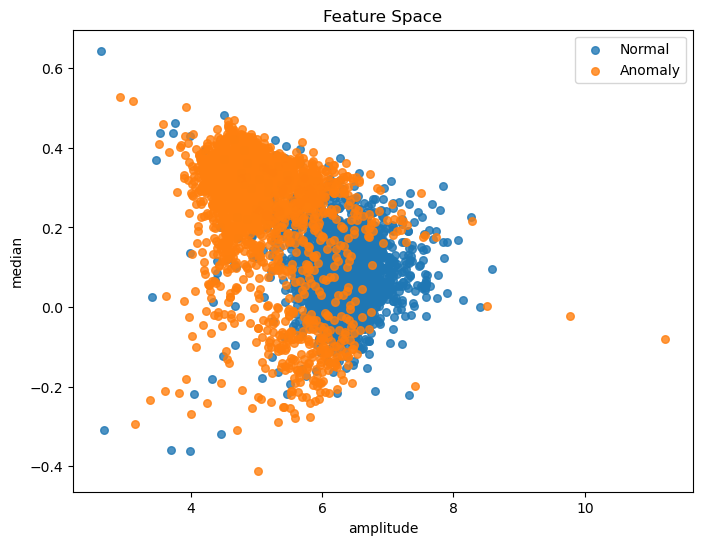

In [19]:
plot_feature_space(
    df=full_df,
    feature_columns=['amplitude', 'median'],
    label_column='label',
    alpha=0.8,
    figsize=(8, 6)
)

## Conclusion

Both Reference Subtraction (macro avg F1-score: 0.94) and Mahalanobis (macro avg F1-score: 0.91) models performed remarkably well. The first because the normal time series closely resemble one another, making the point-wise reference highly representative of the normal class. The second because the anomalies in this dataset exhibit distinct statistical characteristics — particularly in amplitude — that are clearly separable from normal series in feature space. This indicates that the dataset can be effectively classified using simple models, without explicitly considering the sequential and temporal patterns within the series.
This raises two important questions for the next experiments:

- Can the Conv1D Autoencoder, by leveraging temporal structure, provide a meaningful improvement over these much simpler approaches?

- How will these same models perform under a more realistic scenario, where the training data contains a small fraction (5-10%) of contamination by anomalous samples?